Yuliia Chernysheva  
September 17, 2026  
CSC 2267

# CIS 2267 - Assignment 4 - Seaborn Visualizations

In this assignment, you'll use a dataset and create plots of various types.  Later you'll enhance them with advanced features.

## Import the dataset

```python
import pandas as pd
pop = pd.read_excel("population_usafacts.xlsx")
pop
```

In [1]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

In [2]:
pop = pd.read_excel("population_usafacts.xlsx")
pop

,Year,Total,Alabama,Alaska,Arizona,Arkansas,California,Colorado,Connecticut,Delaware,...,South Dakota,Tennessee,Texas,Utah,Vermont,Virginia,Washington,West Virginia,Wisconsin,Wyoming
0,1900,76094000,1830000,NaN,124000,1314000,1490000,543000,910000,185000,...,403000,2023000,3055000,277000,344000,1858000,523000,959000,2072000,93000
1,1901,77584000,1907000,NaN,131000,1341000,1550000,581000,931000,187000,...,418000,2041000,3132000,284000,347000,1887000,583000,972000,2109000,100000
2,1902,79163000,1935000,NaN,138000,1360000,1623000,621000,952000,188000,...,431000,2060000,3210000,292000,349000,1894000,651000,1000000,2141000,105000
3,1903,80632000,1957000,NaN,144000,1384000,1702000,652000,972000,190000,...,437000,2082000,3291000,299000,350000,1890000,719000,1037000,2171000,108000
4,1904,82166000,1978000,NaN,151000,1419000,1792000,659000,987000,192000,...,452000,2086000,3374000,308000,353000,1889000,782000,1064000,2202000,111000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
116,2016,323071755,4866824,742575.0,6944767,2991815,39149186,5543844,3579830,949989,...,863693,6651277,27914064,3044241,624366,8417651,7299961,1832435,5775170,585243
117,2017,325122128,4877989,740983.0,7048088,3003855,39337785,5617421,3575324,957942,...,873732,6714748,28291024,3103540,625132,8471011,7427951,1818683,5793147,579994
118,2018,326838199,4891628,736624.0,7164228,3012161,39437463,5697155,3574561,966985,...,879386,6778180,28624564,3155153,624802,8510920,7526793,1805953,5809319,579054
119,2019,328329953,4907965,733603.0,7291843,3020985,39437610,5758486,3566022,976668,...,887127,6830325,28986794,3203383,624046,8556642,7614024,1795263,5824581,580116


## Extract the columns; Melt the data

Seaborn plots work better with long data, so we use the `melt` function, using columns for only the states we're interested in.

```python
oki = pop.melt(
    id_vars=["Year"],
    value_vars=["Ohio","Kentucky","Indiana"],
    var_name="State",
    value_name="Population")
oki
```

In [3]:
oki = pop.melt(
    id_vars=["Year"],
    value_vars=["Ohio","Kentucky","Indiana"],
    var_name="State",
    value_name="Population")
oki

,Year,State,Population
0,1900,Ohio,4161000
1,1901,Ohio,4216000
2,1902,Ohio,4322000
3,1903,Ohio,4386000
4,1904,Ohio,4458000
...,...,...,...
358,2016,Indiana,6637898
359,2017,Indiana,6662068
360,2018,Indiana,6698481
361,2019,Indiana,6731010


## Simple plots with Seaborn

The `relplot` function is a general method for making a variety of plots.  Here the `kind` parameter indicates we want a line plot.

```python
import seaborn as sns
sns.relplot(
    data=oki,
    kind='line',
    x='Year',
    y='Population',
    hue='State')
```

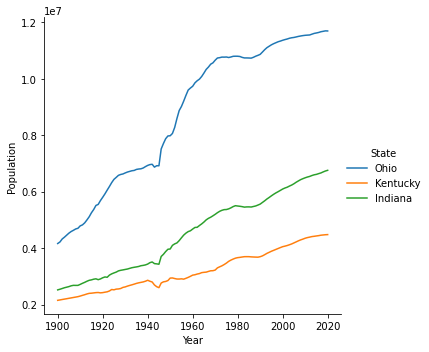

In [4]:
sns.relplot(
    data=oki,
    kind='line',
    x='Year',
    y='Population',
    hue='State')

That works, but isn't much different from what we did with Pandas.  We'll look at other Seaborn enhancements as we go, but let's try one now.  The `palette` option lets us change the colors.  Look at those lovely shades of red!

```python
sns.relplot(
    data=oki,
    kind='line',
    x='Year',
    y='Population',
    hue='State',
    palette='flare')
```

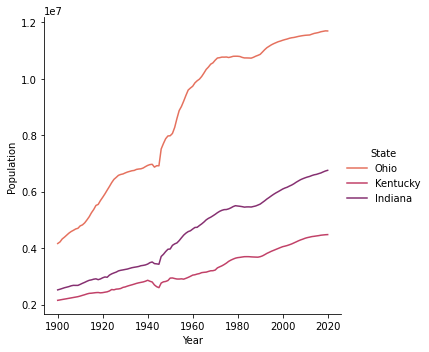

In [5]:
sns.relplot(
    data=oki,
    kind='line',
    x='Year',
    y='Population',
    hue='State',
    palette='flare')

Like Pandas, Seaborn supports sub-plots.

```python
sns.relplot(
    data=oki,
    kind='line',
    x='Year',
    y='Population',
    hue='State',
    col='State',col_wrap=3,
    legend=False)
```

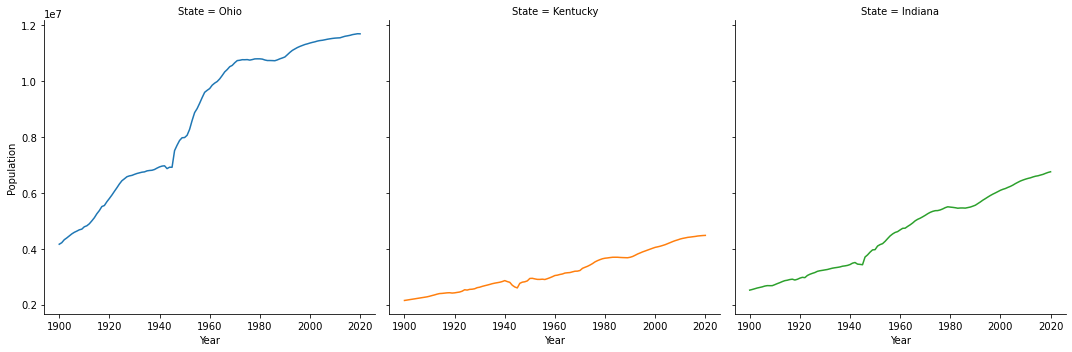

In [6]:
sns.relplot(
    data=oki,
    kind='line',
    x='Year',
    y='Population',
    hue='State',
    col='State', col_wrap=3,
    legend=False
)

Let's return to the combined plot and look at more enhancements.  Seaborn plot functions return an `Axes` object that can be manipulated to add titles and axis labels.  Also, let's fix that "1e7" scientific notation.

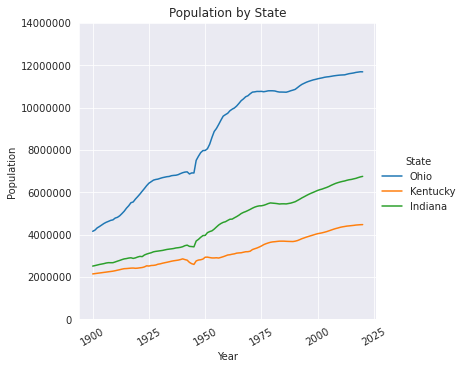

In [7]:
sns.set_style('darkgrid')
g = sns.relplot( 
    kind='line',
    data=oki,
    x='Year',
    y='Population',
    hue='State'
)
for ax in g.axes.flat:
    ax.set(title="Population by State",
          xticks=[x for x in range(1900,2026,25)],
          yticks=[y for y in range(0,14100000,2000000)])
    ax.ticklabel_format(style='plain', axis='y')
    ax.tick_params('x', labelrotation=30)   

Let's save this for inclusion in a presentation

```python
g.savefig("oki.svg")
```

The open with an `svg` viewer.  Most browsers should be able to handle this.  Use the zoom feature to see the benefits of svg.  It doesn't get pixel-y or blurry as you make it bigger.

In [8]:
g.savefig("oki.svg")

# Categorical plots

Let's start with a bar plot.





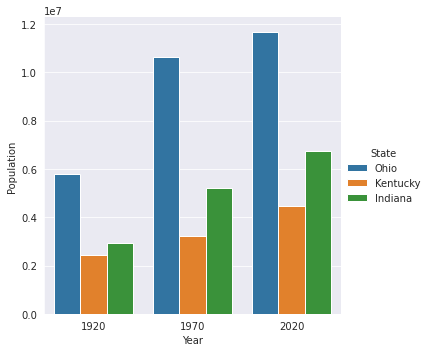

In [9]:
sns.catplot(
    data=oki.query('Year in(1920,1970,2020)'),
    kind='bar',
    x='Year',
    y='Population',
    hue='State'
)

# Distribution plots

Kernel density estimate (KDE) shows the probability of a datapoint ocurring.  Look at Ohio data-- while there is a general overall increase, there are some stalls.  From 1925-1940, the population is flat, and again from 2000 onwards.  Therefore, we expext more population to fall in these date ranges with populations around 7 million and later 11 million.  The KDE shows this.



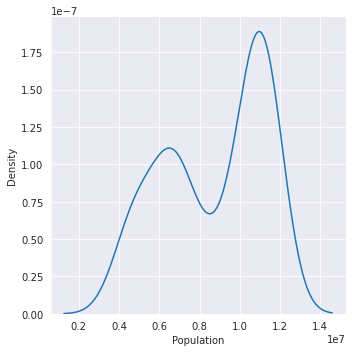

In [10]:
sns.displot(
    data=oki.query('State=="Ohio"'),
    kind='kde',
    x='Population'
)